---
title: null
---


<a id="lineare-regression"></a>

## Lineare Regression

### Ein Beispiel für Projektion: Lineare Regression

**Problemstellung:**

- Oftmals haben wir Messdaten $(x_i,y_i)$, $i=1,\ldots,n$, die aufgrund von Messfehlern nicht exakt einer gegebene Funktion (z.B. einem Polynom) folgen.
- Unser Ziel ist es, eine Gerade

$$
y=ax+b
$$

zu finden, die **am besten zu den Daten passt**.

**Verbindung zur Projektion:**

- Die Aufgabe besteht darin, die Datenpunkte $\mathbf y$ in den durch die Parameter $a$ und $b$ definierten Unterraum zu projizieren.
- Dies minimiert die quadratischen Fehler (Abstände zwischen den Messpunkten und der Geraden).

**Visualisierung:** Unten sehen wir die Messpunkte im Koordinatensystem.

- Der nächste Schritt ist es, die beste Anpassung durch Projektion auf den Unterraum der möglichen Geraden zu berechnen.

### Beste Gerade finden

- Gegeben: Punkte $(x_i,y_i)$, $i=1,\ldots,n$, mit Messfehlern.
- Ziel: Finde die **beste Gerade**

$$
y=ax+b,
$$

die zu den Daten passt.

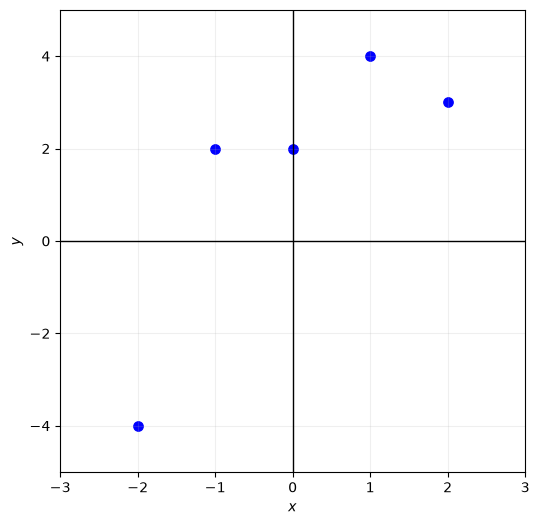

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([-2, -1, 0, 1, 2])
y = np.array([-4, 2, 2, 4, 3])

fig, ax = plt.subplots(figsize=(6, 6))

ax.axhline(0, linewidth=1.0, color="black")
ax.axvline(0, linewidth=1.0, color="black")

ax.scatter(x, y, s=45, color="blue")

ax.set_xlim(-3, 3)
ax.set_ylim(-5, 5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

ax.grid(alpha=0.2)

plt.show()

### Beste Gerade finden

**Frage:** Was bedeutet, die **beste Gerade** zu finden?

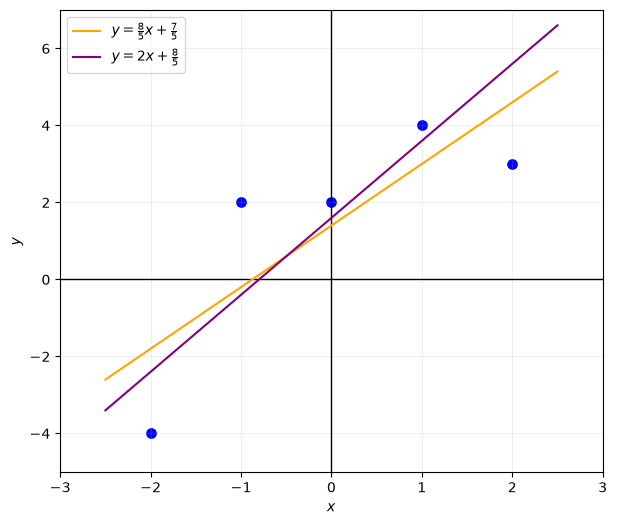

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([-2, -1, 0, 1, 2])
y = np.array([-4, 2, 2, 4, 3])

x_line = np.linspace(-2.5, 2.5, 300)

y1 = (8/5) * x_line + 7/5
y2 = 2 * x_line + 8/5

fig, ax = plt.subplots(figsize=(7, 6))

ax.axhline(0, linewidth=1.0, color="black")
ax.axvline(0, linewidth=1.0, color="black")

ax.scatter(x, y, s=45, color="blue")

ax.plot(
    x_line,
    y1,
    linewidth=1.5,
    color="orange",
    label=r"$y=\frac{8}{5}x+\frac{7}{5}$"
)

ax.plot(
    x_line,
    y2,
    linewidth=1.5,
    color="purple",
    label=r"$y=2x+\frac{8}{5}$"
)

ax.set_xlim(-3, 3)
ax.set_ylim(-5, 7)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

ax.legend()
ax.grid(alpha=0.2)

plt.show()

### Kleinste-Quadrate-Bedingung

- Die Messpunkte $(x_i,y_i)$ und die Punkte auf der Geraden $(x_i,ax_i+b)$ haben eine Abweichung:

$$
y_i-(ax_i+b),
$$

welche minimiert werden soll.

- Die **beste Gerade** minimiert die Summe der Fehlerquadrate:

$$
\sum_{i=1}^{n}
\left(y_i-(ax_i+b)\right)^2.
$$

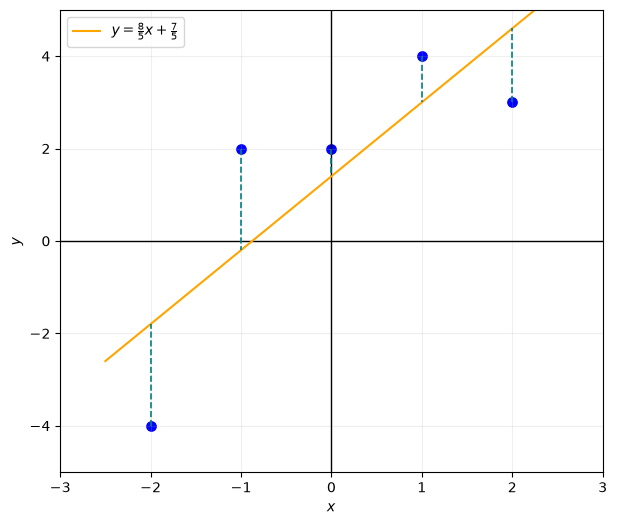

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([-2, -1, 0, 1, 2])
y = np.array([-4, 2, 2, 4, 3])

a = 8/5
b = 7/5

x_line = np.linspace(-2.5, 2.5, 300)
y_line = a * x_line + b

y_hat = a * x + b

fig, ax = plt.subplots(figsize=(7, 6))

ax.axhline(0, linewidth=1.0, color="black")
ax.axvline(0, linewidth=1.0, color="black")

ax.scatter(x, y, s=45, color="blue")

ax.plot(
    x_line,
    y_line,
    linewidth=1.5,
    color="orange",
    label=r"$y=\frac{8}{5}x+\frac{7}{5}$"
)

# Vertikale Abweichungen
for xi, yi, yhi in zip(x, y, y_hat):
    ax.plot(
        [xi, xi],
        [yi, yhi],
        linestyle="--",
        linewidth=1.2,
        color="teal"
    )

ax.set_xlim(-3, 3)
ax.set_ylim(-5, 5)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

ax.legend()
ax.grid(alpha=0.2)

plt.show()

### Formulierung

**Gleichung der besten Gerade:**

$$
ax_1+b=y_1,\qquad
ax_2+b=y_2,\qquad
\ldots,\qquad
ax_n+b=y_n.
$$

**Matrixdarstellung:**

$$
\mathbf A=
\begin{pmatrix}
x_1 & 1\\
x_2 & 1\\
\vdots & \vdots\\
x_n & 1
\end{pmatrix},
\qquad
\boldsymbol{\lambda}
=
\begin{pmatrix}
a\\
b
\end{pmatrix},
\qquad
\mathbf y=
\begin{pmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{pmatrix}.
$$

**Überbestimmtes lineares System:**

$$
\mathbf A\boldsymbol{\lambda}
=
\mathbf y.
$$

In der Regel ist keine exakte Lösung für dieses System möglich.

### Lösung des überbestimmten Systems

**Eindeutige Lösung:**

- Das System

$$
\mathbf A\boldsymbol{\lambda}=\mathbf y
$$

hat eine **eindeutige Lösung**, wenn $\mathbf y$ im Bild $(\operatorname{Im}(\mathbf A))$ der Matrix $\mathbf A$ liegt.

- In diesem Fall existiert eine Gerade

$$
y=ax+b,
$$

die **alle Messpunkte genau trifft**.

**Falls**

$$
\mathbf y\notin\operatorname{Im}(\mathbf A):
$$

- Es ist keine exakte Lösung möglich.
- Stattdessen sucht man den Vektor

$$
\hat{\mathbf y}\in\operatorname{Im}(\mathbf A),
$$

der die quadratische Abweichung

$$
\|\hat{\mathbf y}-\mathbf y\|^2
$$

minimiert.

- Dieser Vektor definiert eine Gerade $y=ax+b$, die den Messpunkten am nächsten liegt.

**Resultierende Lösung:**

- Die Lösung ist eine Projektion von $\mathbf y$ auf den Unterraum $\operatorname{Im}(\mathbf A)$:

$$
\hat{\mathbf y}
=
P_{\mathbf A}\mathbf y,
$$

wobei

$$
P_{\mathbf A}
=
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top.
$$

- Die gesuchte Gerade minimiert die Summe der quadratischen Fehler.

<a id="methode-kleinste-quadrate"></a>

## Methode der kleinsten Quadraten

### Kleinste-Quadrate-Lösung

Da der Vektor $\hat{\mathbf y}$ im Bild von $\mathbf A$ liegen soll, kann er als

$$
\mathbf A\boldsymbol{\lambda}
$$

dargestellt werden, wobei $\boldsymbol{\lambda}$ ein Vektor der unbekannten Koeffizienten ist.

Dies bedeutet, dass $\hat{\mathbf y}$ als Linearkombination der Spalten von $\mathbf A$ ausgedrückt wird.

Die **Beste Lösung im Sinne der kleinsten Quadraten** minimiert den Fehler:

$$
\|\mathbf A\boldsymbol{\lambda}-\mathbf y\|^2.
$$

**Lösung durch Projektion:**

- Projektion von $\mathbf y$ auf den Unterraum, der von den Spalten von $\mathbf A$ aufgespannt wird:

$$
\mathbf A^\top\mathbf A\boldsymbol{\lambda}
=
\mathbf A^\top\mathbf y.
$$

- Die Lösung ist:

$$
\boldsymbol{\lambda}
=
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top\mathbf y.
$$

### Lineare Regression

**Messdaten**

| $x_i$ | -2 | -1 | 0 | 1 | 2 |
|---:|---:|---:|---:|---:|---:|
| $y_i$ | -4 | 2 | 2 | 4 | 3 |

**Lineares Modell**

$$
\hat y=ax+b.
$$

**Matrixdarstellung:**

$$
\mathbf A\boldsymbol{\lambda}
=
\mathbf y,
$$

mit

$$
\mathbf A=
\begin{pmatrix}
-2 & 1\\
-1 & 1\\
0 & 1\\
1 & 1\\
2 & 1
\end{pmatrix},
\qquad
\boldsymbol{\lambda}
=
\begin{pmatrix}
a\\
b
\end{pmatrix},
\qquad
\mathbf y=
\begin{pmatrix}
-4\\
2\\
2\\
4\\
3
\end{pmatrix}.
$$

### Berechnung der Lösung

**Schritte:**

1. Berechne $\mathbf A^\top\mathbf A$ und $\mathbf A^\top\mathbf y$:

$$
\mathbf A^\top\mathbf A
=
\begin{pmatrix}
10 & 0\\
0 & 5
\end{pmatrix},
\qquad
\mathbf A^\top\mathbf y
=
\begin{pmatrix}
16\\
7
\end{pmatrix}.
$$

2. Löse das Gleichungssystem:

$$
\mathbf A^\top\mathbf A
\boldsymbol{\lambda}
=
\mathbf A^\top\mathbf y.
$$

3. Ergebnis:

$$
a=\frac85,
\qquad
b=\frac75.
$$

In [4]:
import numpy as np

A = np.array([
    [-2, 1],
    [-1, 1],
    [ 0, 1],
    [ 1, 1],
    [ 2, 1]
], dtype=float)

y = np.array([-4, 2, 2, 4, 3], dtype=float)

ATA = A.T @ A
ATy = A.T @ y

lambda_hat = np.linalg.solve(ATA, ATy)

print("A^T A =")
print(ATA)

print("\nA^T y =")
print(ATy)

print("\nLösung [a, b] =")
print(lambda_hat)

A^T A =
[[10.  0.]
 [ 0.  5.]]

A^T y =
[16.  7.]

Lösung [a, b] =
[1.6 1.4]


### Beste Gerade

**Interpretation:**

- Die Gerade

$$
y=\frac85x+\frac75
$$

minimiert die quadratische Abweichung zwischen den Messpunkten und der Gerade.

- Der Fehlervektor ist orthogonal zum aufgespannten Unterraum von $\mathbf A$.

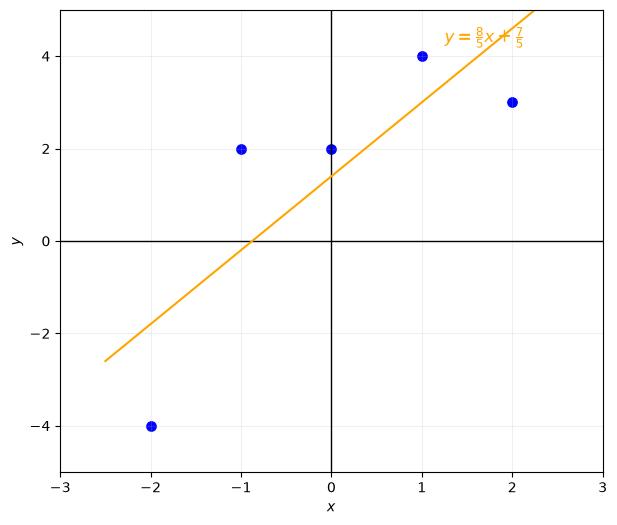

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([-2, -1, 0, 1, 2])
y = np.array([-4, 2, 2, 4, 3])

a = 8/5
b = 7/5

x_line = np.linspace(-2.5, 2.5, 300)
y_line = a * x_line + b

fig, ax = plt.subplots(figsize=(7, 6))

ax.axhline(0, linewidth=1.0, color="black")
ax.axvline(0, linewidth=1.0, color="black")

ax.scatter(x, y, s=45, color="blue")

ax.plot(
    x_line,
    y_line,
    linewidth=1.5,
    color="orange"
)

ax.text(
    1.25,
    4.3,
    r"$y=\frac{8}{5}x+\frac{7}{5}$",
    color="orange",
    fontsize=12
)

ax.set_xlim(-3, 3)
ax.set_ylim(-5, 5)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

ax.grid(alpha=0.2)

plt.show()

### Kleinste-Quadrate und Projektion

**Problem:** Finde die Lösung, die die Summe der Quadrate der Fehler minimiert:

$$
\|\mathbf A\boldsymbol{\lambda}-\mathbf y\|^2.
$$

**1. Minimierungsproblem:**

- Der Fehlervektor ist:

$$
\mathbf r
=
\mathbf A\boldsymbol{\lambda}
-
\mathbf y.
$$

- Ziel: Minimieren der Fehlerquadratsumme:

$$
f(\boldsymbol{\lambda})
=
\|\mathbf r\|^2
=
\|\mathbf A\boldsymbol{\lambda}-\mathbf y\|^2.
$$

**2. Bedingung für ein Minimum:**

- Die Ableitung von $f(\boldsymbol{\lambda})$ nach $\boldsymbol{\lambda}$ wird nullgesetzt:

$$
\frac{\partial}{\partial\boldsymbol{\lambda}}
\|\mathbf A\boldsymbol{\lambda}-\mathbf y\|^2
=
0.
$$

- Nach der Regel für quadratische Formen ergibt sich:

$$
2\mathbf A^\top
(\mathbf y-\mathbf A\boldsymbol{\lambda})
=
0.
$$

- Umstellen liefert:

$$
\mathbf A^\top\mathbf A\boldsymbol{\lambda}
=
\mathbf A^\top\mathbf y.
$$

### Projektion als Lösung des Minimierungsproblems

**3. Lösung durch Projektion:**

- Das Gleichungssystem

$$
\mathbf A^\top\mathbf A\boldsymbol{\lambda}
=
\mathbf A^\top\mathbf y
$$

beschreibt die Projektion von $\mathbf y$ auf den von $\mathbf A$ aufgespannten Unterraum.

- Die Lösung ist:

$$
\boldsymbol{\lambda}
=
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top\mathbf y.
$$

- Der projizierte Vektor ist:

$$
\hat{\mathbf y}
=
\mathbf A\boldsymbol{\lambda}
=
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top\mathbf y.
$$

**4. Verbindung:**

- Die Lösung des Minimierungsproblems entspricht der Projektion von $\mathbf y$ auf den Unterraum von $\mathbf A$.

- Der Restvektor

$$
\mathbf r
=
\mathbf y-\hat{\mathbf y}
$$

ist orthogonal zum Unterraum:

$$
\mathbf A^\top\mathbf r
=
0.
$$

<a id="verknuepfung-lineare-abbildungen"></a>

## Verknüpfung linearer Abbildungen

**Grundlage:** Die Zusammensetzung zweier linearer Abbildungen lässt sich durch das Produkt ihrer Matrizen darstellen.

Gegeben seien zwei lineare Abbildungen:

$$
T_1:\mathbb R^n\to\mathbb R^m,
\qquad
T_1(\mathbf x)=\mathbf A\mathbf x,
$$

$$
T_2:\mathbb R^m\to\mathbb R^k,
\qquad
T_2(\mathbf y)=\mathbf B\mathbf y.
$$

Die Verknüpfung $T_2\circ T_1$ ist ebenfalls linear:

$$
(T_2\circ T_1)(\mathbf x)
=
T_2(T_1(\mathbf x))
=
\mathbf B(\mathbf A\mathbf x)
=
(\mathbf B\mathbf A)\mathbf x.
$$

Das Matrixprodukt

$$
\mathbf B\mathbf A
$$

beschreibt also die Matrixdarstellung der verknüpften Abbildung.

### Verknüpfung linearer Abbildungen

**Beispiel:** Betrachten wir eine Projektion $P$ auf einen Unterraum $U$ (mit Matrix $\mathbf{P_A}$) und eine anschließende Transformation $T$ (mit Matrix $\mathbf B$):

- Die Projektion $P$ auf $U$ ist definiert als:

$$
P(\mathbf x)
=
\mathbf{P_A}\mathbf x,
\qquad
\text{wobei }
\mathbf{P_A}^2=\mathbf{P_A}.
$$

- Die anschließende Transformation $T$ ist gegeben durch:

$$
T(\mathbf y)
=
\mathbf B\mathbf y.
$$

- Die kombinierte Abbildung ist:

$$
(T\circ P)(\mathbf x)
=
T(P(\mathbf x))
=
\mathbf B(\mathbf{P_A}\mathbf x)
=
(\mathbf B\mathbf{P_A})\mathbf x.
$$

**Fazit:** Die Matrix der verknüpften Abbildung $T\circ P$ ist das Produkt der Matrizen $\mathbf B$ und $\mathbf{P_A}$.